<a href="https://colab.research.google.com/github/RamyAkin/AI-Models/blob/main/UnsupervisedModel1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UnSupervised Model Learning for Facial Feature Detectetion

In [ ]:
import cv2
import numpy as np
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/haarcascade_frontalface_default.xml")

In [ ]:
def load_and_detect_faces(folder_path):
    images = []
    labels = []
    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)
        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    faces = face_cascade.detectMultiScale(img, scaleFactor= 1.1, minNeighbors=5, minSize=(30, 30))
                    for (x, y ,w, h) in faces:
                       face_region = img[y:y+h, x:x+w]
                       images.append(face_region)
                       labels.append(label)
                else:
                    print(f"Could not load image: {img_path}")
    return images, labels

In [ ]:
radius =1
n_points= 8 * radius


def extract_lbp_features(images):
    lbp_features = []
    for img in images:
      # Resize face image to a standard size if needed
      img = cv2.resize(img, (64, 64)) # Standardize size
      Ibp = local_binary_pattern(img, n_points, radius, method="uniform")
      # Histogram of LBP patterns
      (hist, _) = np.histogram(Ibp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
      #Normalize the histogram
      hist = hist.astype("float")
      hist /= (hist.sum() + 1e-6)
      lbp_features. append(hist)
    return np.array(lbp_features)

In [ ]:
train_folder_path = "/content/drive/My Drive/UniWork3rdYear/CK_dataset/train"
test_folder_path = "/content/drive/My Drive/UniWork3rdYear/CK_dataset/test"

x_train_faces, y_train = load_and_detect_faces(train_folder_path)
x_train_features = extract_lbp_features(x_train_faces)

x_test_faces, y_test = load_and_detect_faces(test_folder_path)
x_test_features = extract_lbp_features(x_test_faces)


In [ ]:
#Initializatin of the DTC
tree_classifier = DecisionTreeClassifier(max_depth=10)
#Training on the training data.
tree_classifier.fit(x_train_features, y_train)

DecisionTreeClassifier(max_depth=10)

In [ ]:
#Predicting on the test set
y_pred = tree_classifier.predict(x_test_features)

#Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy *100:.2f}%")
#Displaying confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy Score: 22.30%
Confusion Matrix:
[[ 5  0  5  6  0  2]
 [ 2  0  0  3  1  1]
 [ 4  1  9  9  6  6]
 [11  4  5  5  4  7]
 [ 3  3  1  2  3  5]
 [ 5  2  5  8  4 11]]


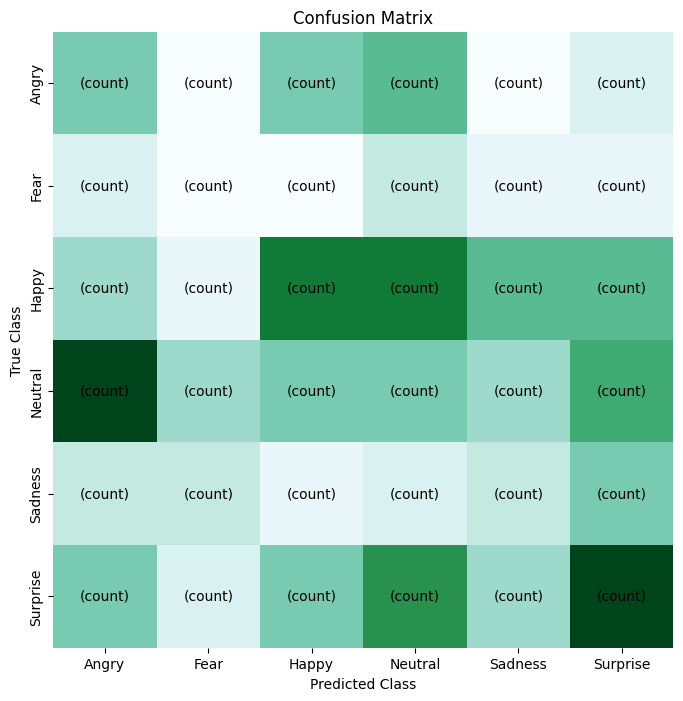

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
# Assuming class names are defined
class_names = ["Angry", "Fear", "Happy", "Neutral", "Sadness", "Surprise"]
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Calculate percentages
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100
# Plot confusion matrix with class names
plt.figure(figsize= (8, 8))
ax = sns. heatmap(conf_matrix, annot=False, cmap="BuGn", xticklabels=class_names, yticklabels=class_names, cbar=False)
# Add annotations with both counts and percentages
for i in range(conf_matrix.shape[0]) :
  for j in range(conf_matrix. shape[1]) :
    count = conf_matrix[i, i]
    ax. text(j + 0.5, i + 0.5, f"(count)", ha="center", va="center", color="black", fontsize=10)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Function to predict and display the expression of a single image
def predict_emotion (image_path, model):
    img= cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found or could not be loaded.")
#Detect face
faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
if len(faces) == 0:
    print("No face detected.")
    return

for (X, y, W, h) in faces:
    face_region = img[y:yth, x:x+w]
    face_region = cv2.resize(face_region, (64, 64))
    Ibp = local_binary_pattern(face_region, n_points, radius, method="uniform")
    # Histogram of LBP patterns
    hist, _= np.histogram(1bp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    # Predict expression
    features = hist.reshape(1, -1)
    predicted_expression = model.predict(features)[e]
    img_rgb=cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    # Draw a rectangle around the detected face in the color image
    img_with_box=img_rgb.copy()
    cv2. rectangle(img_with_box, (X,y), (x+W,y+h), (255, 0, 0),1) # Red rectangle
    plt.figure(figsize=(18, 6))
  # Display the image with predicted label
    plt.subplot (1, 3, 1)
    plt.imshow(img_with_box)
    plt.title(f"Face detection in the original image")
    plt.axis('off')
    # 1st subplot: Original image with predicted expression label
    plt.subplot(1,3, 2)
    plt.imshow(img_rgb)
    plt.title(f"Predicted Expression: {predicted_expression}")
    plt.axis('off')
    plt.show()
#Example path to an image
image_path = "/content/drive/My Drive/testimages/testimages/24.tiff"
predict_emotion (image_path, tree_classifier)